In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct.round(2)
}).sort_values("missing_pct", ascending=False)

missing_summary

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
survived,0,0.00
pclass,0,0.00
sex,0,0.00
sibsp,0,0.00
parch,0,0.00
fare,0,0.00


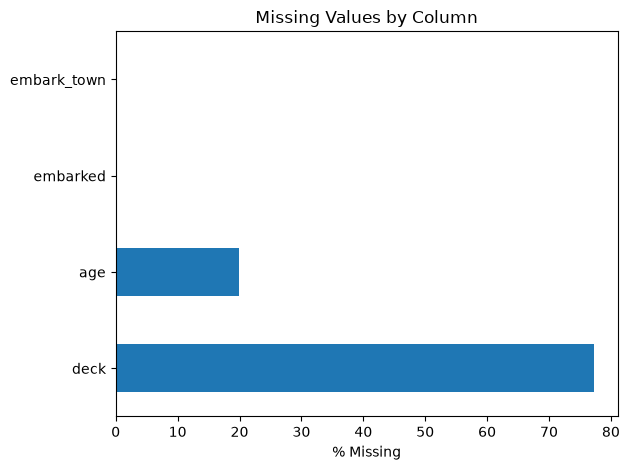

In [5]:
missing_summary[missing_summary["missing_count"] > 0]["missing_pct"].plot(kind="barh")
plt.xlabel("% Missing")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

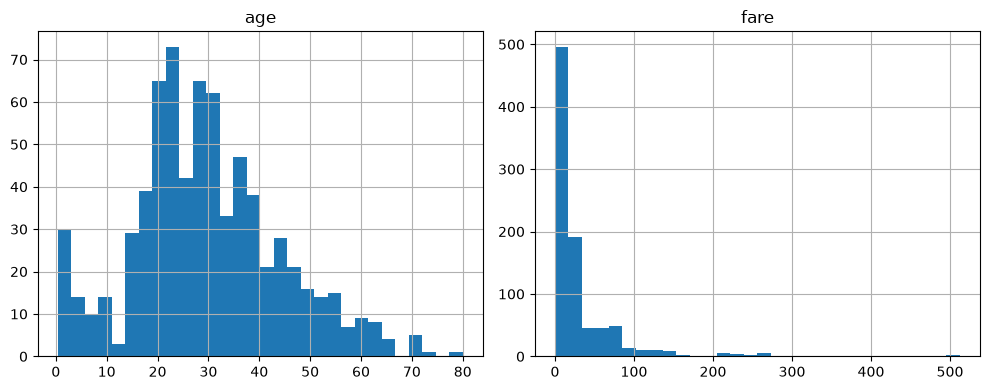

In [6]:
df[["age", "fare"]].hist(bins=30, figsize=(10, 4))
plt.tight_layout()
plt.show()

In [7]:
print("Fully duplicate rows:", df.duplicated().sum())

Fully duplicate rows: 107


In [8]:
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [9]:
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [10]:
print("Fully duplicate rows:", df.duplicated().sum())

Fully duplicate rows: 107


In [11]:
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- sex ---
<StringArray>
['male', 'female']
Length: 2, dtype: str

--- embarked ---
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

--- class ---
<StringArray>
['Third', 'First', 'Second']
Length: 3, dtype: str

--- who ---
<StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str

--- deck ---
<StringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Length: 8, dtype: str

--- embark_town ---
<StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str

--- alive ---
<StringArray>
['no', 'yes']
Length: 2, dtype: str



/var/folders/tp/yzt5h2f10yq_hn5pnfvv_92r0000gn/T/ipykernel_4892/972568144.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [12]:
categorical_cols = df.select_dtypes(include=["object", "str"]).columns
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- sex ---
<StringArray>
['male', 'female']
Length: 2, dtype: str

--- embarked ---
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

--- class ---
<StringArray>
['Third', 'First', 'Second']
Length: 3, dtype: str

--- who ---
<StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str

--- deck ---
<StringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Length: 8, dtype: str

--- embark_town ---
<StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str

--- alive ---
<StringArray>
['no', 'yes']
Length: 2, dtype: str



## Data Quality Audit — Titanic Dataset

| Issue | Severity | Proposed Fix |
|---|---|---|
| `age` has 19.87% missing values (177 of 891 rows) | High | Impute with median age, or add an `age_missing` flag column |
| `deck` has 77.22% missing values (688 of 891 rows) | High | Consider dropping the column — too sparse to be useful for analysis |
| `embarked` / `embark_town` each have 0.22% missing values (2 rows) | Low | Drop the 2 affected rows, or fill with the most common port |
| `fare` is right-skewed with high-value outliers (max 512 vs median 14.45) | Medium | Investigate outliers individually before deciding to cap or log-transform — not necessarily data errors |
| No unique passenger ID column exists | Low | Use DataFrame index as a proxy identifier if one is needed |
| 107 fully duplicate rows found (~12% of dataset) | High | Investigate whether duplicates are genuine repeated records or a data-loading artifact; if artifact, drop with `df.drop_duplicates()` |
| All categorical columns (`sex`, `class`, `who`, `embarked`, `embark_town`, `alive`) use consistent, clean labels | None | No inconsistent spelling/casing issues found |